In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import seaborn as sns
from datetime import datetime
import json
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [27]:
ck = pd.read_csv('ck-public.csv')
annonimized = pd.read_csv('annonimized.csv')

print("Size of qt dataset:", ck.shape)
print("Size of annonimized dataset:", annonimized.shape)


Size of qt dataset: (761, 2)
Size of annonimized dataset: (295198, 11)


In [28]:

print(f"\nNumber of unique students: {annonimized['concat(\'it001\', username)'].nunique()}")
print(f"Number of unique assignments: {annonimized['concat(\'it001\',`assignment_id`)'].nunique()}")
print(f"Number of unique problems: {annonimized['concat(\'it001\',`problem_id`)'].nunique()}")


Number of unique students: 1489
Number of unique assignments: 203
Number of unique problems: 469


In [29]:
# Làm sạch tên cột và chuẩn bị dữ liệu
df = annonimized.copy()
df.columns = [
    "assignment_id", "problem_id", "student", "is_final", "status", 
    "pre_score", "coefficient", "language_id", "created_at", "updated_at", "judgement"
]

# Chuyển đổi thời gian
df['created_at'] = pd.to_datetime(df['created_at'], format='%m-%d %H:%M:%S', errors='coerce')
df['updated_at'] = pd.to_datetime(df['updated_at'], format='%m-%d %H:%M:%S', errors='coerce')

# Trích xuất thông tin từ judgement JSON
def parse_judgement(judgement_str):
    try:
        judgement = json.loads(judgement_str)
        return {
            'avg_time': np.mean(judgement.get('times', [0])),
            'avg_memory': np.mean(judgement.get('mems', [0])),
            'total_wrong': judgement.get('verdicts', {}).get('WRONG', 0),
            'total_tle': judgement.get('verdicts', {}).get('Time Limit Exceeded', 0),
            'total_runtime_error': judgement.get('verdicts', {}).get('Runtime Error', 0),
        }
    except:
        return {
            'avg_time': 0, 'avg_memory': 0, 'total_wrong': 0, 
            'total_tle': 0, 'total_runtime_error': 0, 'total_compile_error': 0
        }

judgement_features = df['judgement'].apply(parse_judgement)
judgement_df = pd.DataFrame(list(judgement_features))
df = pd.concat([df, judgement_df], axis=1)

print("Đã parse judgement thành công!")
df.head()

Đã parse judgement thành công!


,assignment_id,problem_id,student,is_final,status,pre_score,coefficient,language_id,created_at,updated_at,judgement,avg_time,avg_memory,total_wrong,total_tle,total_runtime_error,total_compile_error
0,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,1900-10-09 08:02:04,1900-10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,10,0,0,NaN
1,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,0,SCORE,0,100,it0012,1900-10-09 08:04:41,1900-10-09 08:04:51,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,10,0,0,NaN
2,90ce27571176d87961b565d5ef4b3de33ede04ac,789454427dd4097a14749e3dde63346b7a8d3811,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,1900-10-09 08:06:49,1900-10-09 08:06:58,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,0,0,0,0.0
3,90ce27571176d87961b565d5ef4b3de33ede04ac,bf96fbdc5f499538c3e2bfbec5779c8a14b0a9ff,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,1900-10-09 08:47:52,1900-10-09 08:48:01,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,0,0,0,0.0
4,90ce27571176d87961b565d5ef4b3de33ede04ac,7a6e5ca470ff47c3b5048f240c4738de71010c78,ed9eaeb6a707f50154024b24d7efcb874a9795dd,1,SCORE,10000,100,it0012,1900-10-09 09:19:35,1900-10-09 09:19:45,"{""times"":[0,0,0,0,0,0,0,0,0,0],""mems"":[0,0,0,0...",0.0,0.0,0,0,0,0.0


In [30]:
# Tính toán các đặc trưng thời gian
df['hour'] = df['created_at'].dt.hour
df['day_of_week'] = df['created_at'].dt.dayofweek  # 0=Monday, 6=Sunday

# Phân loại thời gian làm việc
def categorize_work_time(hour):
    if 6 <= hour <= 18:
        return 'day_time'  # Giờ hành chính
    elif 19 <= hour <= 23:
        return 'evening'   # Buổi tối
    else:
        return 'late_night'  # Đêm khuya/sáng sớm (chăm chỉ hơn)

df['work_time_category'] = df['hour'].apply(categorize_work_time)

# Tính số ngày từ khi bắt đầu course
course_start = df['created_at'].min()
df['days_from_start'] = (df['created_at'] - course_start).dt.days

print("Đã tạo các đặc trưng thời gian!")

Đã tạo các đặc trưng thời gian!


In [31]:
# Tính độ khó của bài tập dựa trên tỷ lệ AC (Accepted)
problem_difficulty = df.groupby('problem_id').agg({
    'pre_score': lambda x: (x == 10000).mean(),  # Tỷ lệ AC
    'student': 'nunique'  # Số sinh viên thử làm
}).rename(columns={'pre_score': 'problem_ac_rate', 'student': 'problem_attempts'})

# Bài khó = tỷ lệ AC thấp
problem_difficulty['problem_difficulty'] = 1 - problem_difficulty['problem_ac_rate']

# Merge difficulty score vào dataframe chính
df = df.merge(problem_difficulty, left_on='problem_id', right_index=True, how='left')

print("Đã tính độ khó bài tập!")
print(f"Bài khó nhất có tỷ lệ AC: {problem_difficulty['problem_ac_rate'].min():.3f}")
print(f"Bài dễ nhất có tỷ lệ AC: {problem_difficulty['problem_ac_rate'].max():.3f}")

Đã tính độ khó bài tập!
Bài khó nhất có tỷ lệ AC: 0.000
Bài dễ nhất có tỷ lệ AC: 1.000


In [32]:
def extract_student_features(df):
    """Trích xuất đặc trưng cho từng sinh viên"""
    
    student_features = []
    
    for student in df['student'].unique():
        student_data = df[df['student'] == student].copy()
        
        features = {'student': student}
        
        # === BASIC FEATURES ===
        features['total_submissions'] = len(student_data)
        features['unique_problems'] = student_data['problem_id'].nunique()
        features['unique_assignments'] = student_data['assignment_id'].nunique()
        features['final_submissions'] = student_data['is_final'].sum()
        
        # === PERFORMANCE FEATURES ===
        features['avg_score'] = student_data['pre_score'].mean()
        features['max_score'] = student_data['pre_score'].max()
        features['perfect_scores'] = (student_data['pre_score'] == 10000).sum()
        features['perfect_score_rate'] = features['perfect_scores'] / features['total_submissions']
        features['successful_submissions'] = (student_data['status'] == 'SCORE').sum()
        features['success_rate'] = features['successful_submissions'] / features['total_submissions']
        
        # === EFFORT & PERSISTENCE FEATURES ===
        features['avg_attempts_per_problem'] = features['total_submissions'] / max(features['unique_problems'], 1)
        features['late_submissions'] = (student_data['coefficient'] < 100).sum()
        features['late_submission_rate'] = features['late_submissions'] / features['total_submissions']
        
        # === DIFFICULTY FEATURES ===
        features['avg_problem_difficulty'] = student_data['problem_difficulty'].mean()
        features['max_problem_difficulty'] = student_data['problem_difficulty'].max()
        hard_problems = student_data[student_data['problem_difficulty'] > 0.7]  # Bài khó
        features['hard_problems_attempted'] = len(hard_problems)
        features['hard_problems_solved'] = (hard_problems['pre_score'] == 10000).sum()
        features['hard_problem_success_rate'] = (
            features['hard_problems_solved'] / max(features['hard_problems_attempted'], 1)
        )
        
        # === TIME PATTERN FEATURES (Tính chăm chỉ) ===
        features['late_night_submissions'] = (student_data['work_time_category'] == 'late_night').sum()
        features['weekend_submissions'] = (student_data['day_of_week'].isin([5, 6])).sum()
        features['late_night_rate'] = features['late_night_submissions'] / features['total_submissions']
        features['weekend_rate'] = features['weekend_submissions'] / features['total_submissions']
        
        # Consistency - Tính đều đặn trong học tập
        daily_submissions = student_data.groupby(student_data['created_at'].dt.date).size()
        features['active_days'] = len(daily_submissions)
        features['max_daily_submissions'] = daily_submissions.max() if len(daily_submissions) > 0 else 0
        features['avg_daily_submissions'] = daily_submissions.mean() if len(daily_submissions) > 0 else 0
        features['consistency_score'] = features['active_days'] / max(student_data['days_from_start'].max(), 1)
        
        # === ERROR ANALYSIS FEATURES ===
        features['avg_wrong_answers'] = student_data['total_wrong'].mean()
        features['avg_tle'] = student_data['total_tle'].mean()
        features['avg_runtime_errors'] = student_data['total_runtime_error'].mean()
        features['avg_compile_errors'] = student_data['total_compile_error'].mean()
        
            
        # === EFFICIENCY FEATURES ===
        features['avg_execution_time'] = student_data['avg_time'].mean()
        features['avg_memory_usage'] = student_data['avg_memory'].mean()
        
        student_features.append(features)
    
    return pd.DataFrame(student_features)

# Tạo features cho tất cả sinh viên
print("Đang trích xuất features cho sinh viên...")
student_features_df = extract_student_features(df)
print(f"Đã tạo {len(student_features_df.columns)-1} features cho {len(student_features_df)} sinh viên")

# Hiển thị các features đã tạo
print("\nCác features đã tạo:")
for i, col in enumerate(student_features_df.columns[1:], 1):
    print(f"{i:2d}. {col}")

Đang trích xuất features cho sinh viên...
Đã tạo 32 features cho 1489 sinh viên

Các features đã tạo:
 1. total_submissions
 2. unique_problems
 3. unique_assignments
 4. final_submissions
 5. avg_score
 6. max_score
 7. perfect_scores
 8. perfect_score_rate
 9. successful_submissions
10. success_rate
11. avg_attempts_per_problem
12. late_submissions
13. late_submission_rate
14. avg_problem_difficulty
15. max_problem_difficulty
16. hard_problems_attempted
17. hard_problems_solved
18. hard_problem_success_rate
19. late_night_submissions
20. weekend_submissions
21. late_night_rate
22. weekend_rate
23. active_days
24. max_daily_submissions
25. avg_daily_submissions
26. consistency_score
27. avg_wrong_answers
28. avg_tle
29. avg_runtime_errors
30. avg_compile_errors
31. avg_execution_time
32. avg_memory_usage


In [33]:
ck['CK'] = pd.to_numeric(ck['CK'], errors='coerce')
final_df = student_features_df.merge(ck[['hash', 'CK']], left_on='student', right_on='hash', how='left')
final_df = final_df.drop(columns=['hash'])

graded_df = final_df[final_df['CK'].notna()].copy()
ungraded_df = final_df[final_df['CK'].isna()].copy()

print(f"Số sinh viên có điểm: {len(graded_df)}")
print(f"Số sinh viên chưa có điểm: {len(ungraded_df)}")

print("\nThống kê điểm TH:")
print(graded_df['CK'].describe())

Số sinh viên có điểm: 755
Số sinh viên chưa có điểm: 734

Thống kê điểm TH:
count    755.000000
mean       5.477483
std        2.152852
min        0.000000
25%        4.000000
50%        5.500000
75%        7.000000
max       10.000000
Name: CK, dtype: float64


In [34]:
X = graded_df.drop(columns=['student', 'CK'])
y = graded_df['CK']

# Handle infinite values and NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

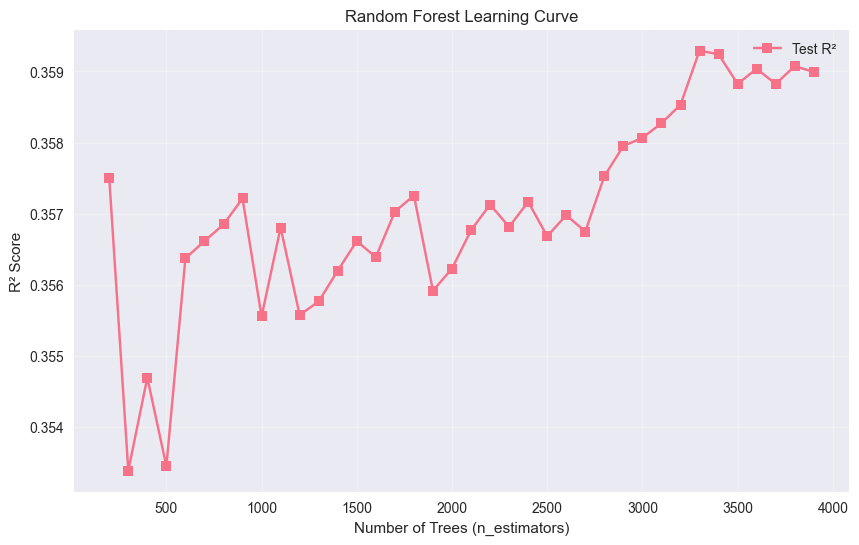

In [35]:
train_scores = []
test_scores = []
best_rf_models = {}
n_estimators_range = range(200, 4000, 100)

for n in n_estimators_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    y_test_pred = rf.predict(X_test)
    test_scores.append(r2_score(y_test, y_test_pred))
    best_rf_models[n] = rf

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, test_scores, label='Test R²', marker='s')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('R² Score')
plt.title('Random Forest Learning Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Chuẩn bị dữ liệu training
# Train multiple models
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=2100, random_state=42),
}

results = {}

for name, model in models.items():
    if name == 'Linear Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'model': model,
        'mse': mse,
        'r2': r2,
        'predictions': y_pred
    }
    
    print(f"{name}:")
    print(f"  R² Score: {r2:.4f}")
    print(f"  MSE: {mse:.4f}")
    print(f"  RMSE: {np.sqrt(mse):.4f}")
    print()

# Chọn model tốt nhất
best_model_name = max(results.keys(), key=lambda x: results[x]['r2'])
best_model = results[best_model_name]['model']

print(f"Model tốt nhất: {best_model_name} (R² = {results[best_model_name]['r2']:.4f})")

Linear Regression:
  R² Score: 0.1087
  MSE: 3.8440
  RMSE: 1.9606

Random Forest:
  R² Score: 0.3568
  MSE: 2.7742
  RMSE: 1.6656

Model tốt nhất: Random Forest (R² = 0.3568)


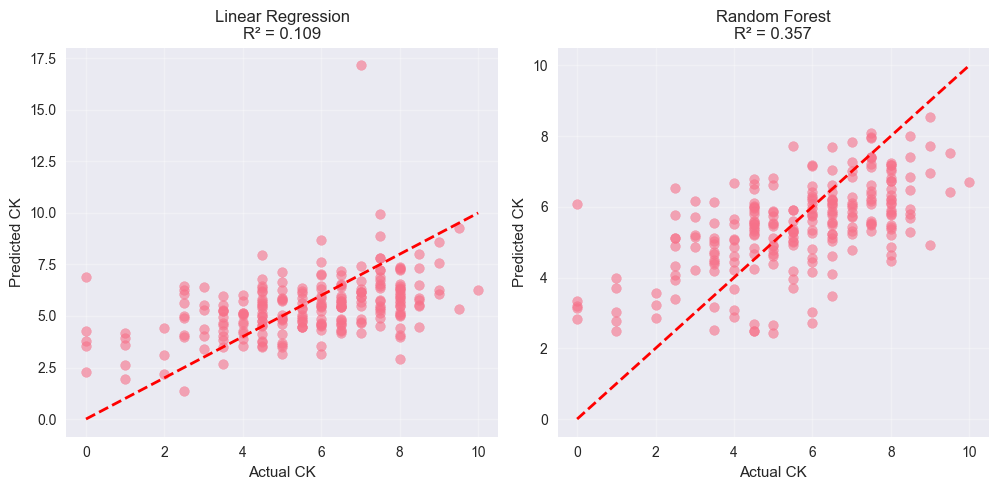

In [24]:
# Visualization: Predicted vs Actual
plt.figure(figsize=(15, 5))

for i, (name, result) in enumerate(results.items(), 1):
    plt.subplot(1, 3, i)
    plt.scatter(y_test, result['predictions'], alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual CK')
    plt.ylabel('Predicted CK')
    plt.title(f'{name}\nR² = {result["r2"]:.3f}')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

THỐNG KÊ DỰ ĐOÁN:
Số sinh viên được dự đoán: 734
Điểm dự đoán trung bình: 5.46
Điểm dự đoán cao nhất: 9.15
Điểm dự đoán thấp nhất: 2.17
Độ lệch chuẩn: 1.27

TOP 10 SINH VIÊN CÓ ĐIỂM DỰ ĐOÁN CAO NHẤT:
 1. cd2cc30c2a3c6b967fc8... : 9.15
 2. cf84076c807f395016ea... : 8.83
 3. a07cb417ba30c0e4d8cc... : 8.70
 4. b51687ca4edcbe2376bc... : 8.68
 5. ae84ba8c1585fe80b8d2... : 8.60
 6. d28c344507f89c41df92... : 8.56
 7. ea8f19a7914d05412dc4... : 8.54
 8. eaad1484ffa24b01432f... : 8.47
 9. e8335df6f0ac481c6ac1... : 8.42
10. f639cf4aa4008b2bf51b... : 8.38

✅ Đã lưu kết quả vào 'enhanced_predicted_ck.csv'


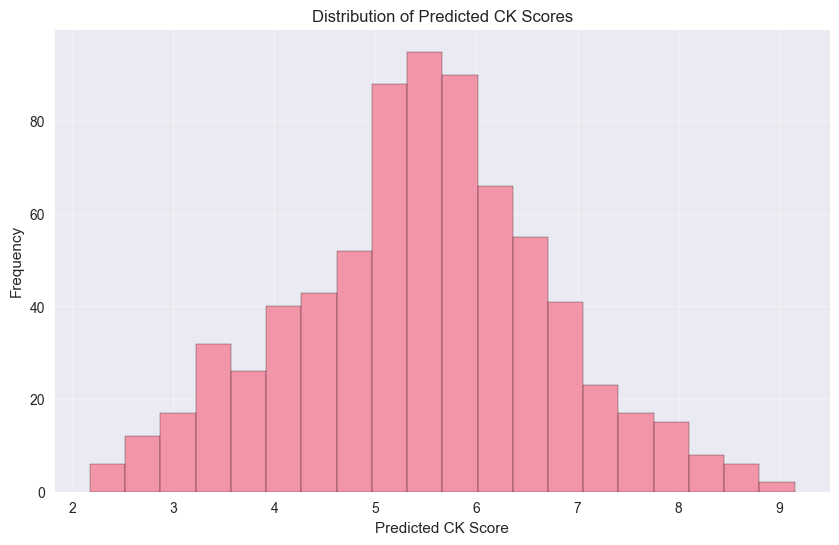

In [25]:
# Dự đoán cho sinh viên chưa có điểm
if len(ungraded_df) > 0:
    X_ungraded = ungraded_df.drop(columns=['student', 'CK'])
    X_ungraded = X_ungraded.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    if best_model_name == 'Linear Regression':
        X_ungraded_scaled = scaler.transform(X_ungraded)
        predictions = best_model.predict(X_ungraded_scaled)
    else:
        predictions = best_model.predict(X_ungraded)
    
    # Tạo DataFrame kết quả
    prediction_results = pd.DataFrame({
        'student': ungraded_df['student'],
        'predicted_CK': predictions
    })
    
    # Thống kê dự đoán
    print("THỐNG KÊ DỰ ĐOÁN:")
    print("=" * 30)
    print(f"Số sinh viên được dự đoán: {len(prediction_results)}")
    print(f"Điểm dự đoán trung bình: {predictions.mean():.2f}")
    print(f"Điểm dự đoán cao nhất: {predictions.max():.2f}")
    print(f"Điểm dự đoán thấp nhất: {predictions.min():.2f}")
    print(f"Độ lệch chuẩn: {predictions.std():.2f}")
    
    # Hiển thị một số sinh viên có điểm dự đoán cao nhất
    print("\nTOP 10 SINH VIÊN CÓ ĐIỂM DỰ ĐOÁN CAO NHẤT:")
    print("=" * 50)
    top_students = prediction_results.sort_values('predicted_CK', ascending=False).head(10)
    for i, (_, row) in enumerate(top_students.iterrows(), 1):
        print(f"{i:2d}. {row['student'][:20]}... : {row['predicted_CK']:.2f}")
    
    # Lưu kết quả
    prediction_results.to_csv('enhanced_predicted_ck.csv', index=False)

    print("\n✅ Đã lưu kết quả vào 'enhanced_predicted_ck.csv'")
    
    # Histogram của dự đoán
    plt.figure(figsize=(10, 6))
    plt.hist(predictions, bins=20, alpha=0.7, edgecolor='black')
    plt.xlabel('Predicted CK Score')
    plt.ylabel('Frequency')
    plt.title('Distribution of Predicted CK Scores')
    plt.grid(True, alpha=0.3)
    plt.show()